## Ferry Capacity Utilization & Operational Efficiency Analytics System

### import libraries 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings("ignore")

## STEP 1 : LOAD THE DATA 

In [2]:
df = pd.read_csv(r"C:\Users\SANDEEP\Downloads\Toronto Island Ferry Tickets.csv")

In [3]:
# Let's look at the data first
print("First 5 rows :")
print("\n")
print(df.head()) 

First 5 rows :


   _id            Timestamp  Redemption Count  Sales Count
0    1  2025-12-21T22:30:00                14           16
1    2  2025-12-21T22:15:00                 1            0
2    3  2025-12-21T22:00:00                 2            0
3    4  2025-12-21T21:30:00                11            1
4    5  2025-12-21T21:15:00                10            0


In [4]:
print("Last 5 rows : ")
print("\n")
print(df.tail())

Last 5 rows : 


           _id            Timestamp  Redemption Count  Sales Count
261533  261534  2015-05-04T16:00:00                 0            2
261534  261535  2015-05-01T16:00:00                 1            0
261535  261536  2015-05-01T15:45:00                 0            1
261536  261537  2015-05-01T15:15:00                 0            2
261537  261538  2015-05-01T13:30:00                 0            1


In [5]:
# column names 
print("\nColumn names:", df.columns.tolist() )


Column names: ['_id', 'Timestamp', 'Redemption Count', 'Sales Count']


In [6]:
print("\nShape (rows, columns):", df.shape)


Shape (rows, columns): (261538, 4)


In [7]:
print("\nData types:\n", df.dtypes)


Data types:
 _id                  int64
Timestamp           object
Redemption Count     int64
Sales Count          int64
dtype: object


In [8]:
print("\nAny missing values?\n", df.isnull().sum())


Any missing values?
 _id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64


## STEP 2 : CONVERT TIMESTAMP COLUMN TO DATETIME 

In [9]:
# converting timestamp column to datetime 
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [10]:
df[["Timestamp"]]

,Timestamp
0,2025-12-21 22:30:00
1,2025-12-21 22:15:00
2,2025-12-21 22:00:00
3,2025-12-21 21:30:00
4,2025-12-21 21:15:00
...,...
261533,2015-05-04 16:00:00
261534,2015-05-01 16:00:00
261535,2015-05-01 15:45:00
261536,2015-05-01 15:15:00


In [11]:
df.dtypes

_id                          int64
Timestamp           datetime64[ns]
Redemption Count             int64
Sales Count                  int64
dtype: object

In [12]:
# sort by time - just good practice for time-series data  
df  = df.sort_values("Timestamp")

In [13]:
df

,_id,Timestamp,Redemption Count,Sales Count
261537,261538,2015-05-01 13:30:00,0,1
261536,261537,2015-05-01 15:15:00,0,2
261535,261536,2015-05-01 15:45:00,0,1
261534,261535,2015-05-01 16:00:00,1,0
261533,261534,2015-05-04 16:00:00,0,2
...,...,...,...,...
4,5,2025-12-21 21:15:00,10,0
3,4,2025-12-21 21:30:00,11,1
2,3,2025-12-21 22:00:00,2,0
1,2,2025-12-21 22:15:00,1,0


In [14]:
# reset row numbers after sorting  
df = df.reset_index(drop = True) 

In [15]:
df

,_id,Timestamp,Redemption Count,Sales Count
0,261538,2015-05-01 13:30:00,0,1
1,261537,2015-05-01 15:15:00,0,2
2,261536,2015-05-01 15:45:00,0,1
3,261535,2015-05-01 16:00:00,1,0
4,261534,2015-05-04 16:00:00,0,2
...,...,...,...,...
261533,5,2025-12-21 21:15:00,10,0
261534,4,2025-12-21 21:30:00,11,1
261535,3,2025-12-21 22:00:00,2,0
261536,2,2025-12-21 22:15:00,1,0


## STEP 3: CHECK FOR DUPLICATE TIMESTAMPS 

In [16]:
# sometimesthe same 15-mins interval might appear twice in the data 

duplicate_count = df["Timestamp"].duplicated().sum()

In [17]:
print("\nNumber of duplicate timestamps:", duplicate_count ) 


Number of duplicate timestamps: 0


## STEP 4 : CHECK FOR NEGATIVE OR WEIRD VALUES 

In [18]:
# A negative ticket count makes no sense (can't sell -5 tickets). 
print("\nMinimum Sales Count:", df["Sales Count"].min())


Minimum Sales Count: 0


In [19]:
print("\nMinimum Redemption Count:", df["Redemption Count"].min())


Minimum Redemption Count: 0


## STEP 5: SMOOTH OUT EXTREME SPIKES (OUTLIERS)

In [20]:
sales_upper_limit = df["Sales Count"].quantile(0.99)
redemption_upper_limit = df["Redemption Count"].quantile(0.99)

print("\n99th percentile Sales Count:", sales_upper_limit)
print("99th percentile Redemption Count:", redemption_upper_limit)

df["sales_is_spike"] = df["Sales Count"] > sales_upper_limit
df["redemption_is_spike"] = df["Redemption Count"] > redemption_upper_limit

print("\nNumber of sales spikes found:", df["sales_is_spike"].sum())
print("Number of redemption spikes found:", df["redemption_is_spike"].sum())



99th percentile Sales Count: 458.0
99th percentile Redemption Count: 508.0

Number of sales spikes found: 2598
Number of redemption spikes found: 2609


In [21]:
spike_days = df[df["sales_is_spike"]]
print(spike_days[["Timestamp", "Sales Count"]].sort_values("Sales Count", ascending=False).head(20))

                 Timestamp  Sales Count
199913 2023-08-15 20:15:00         7229
204264 2023-10-10 14:00:00         5518
221390 2024-06-19 19:00:00         5342
253769 2025-09-01 17:30:00         5218
225326 2024-08-05 22:00:00         4995
227997 2024-09-07 17:00:00         4974
255572 2025-09-24 22:30:00         4015
249886 2025-07-17 23:15:00         3701
196497 2023-07-05 21:15:00         3634
173649 2022-08-15 10:30:00         3408
172136 2022-07-28 12:00:00         3400
223299 2024-07-12 19:45:00         3143
891    2015-05-19 16:30:00         3017
232849 2024-11-13 16:45:00         2863
91711  2019-04-21 20:30:00         2630
31261  2016-09-08 12:45:00         2569
453    2015-05-12 14:00:00         2512
72570  2018-07-08 11:30:00         2469
174856 2022-08-29 21:15:00         2444
149778 2021-09-07 17:00:00         2330


The 99th percentile method was used to identify unusually high ticket sales and redemption activity. Since these observations likely represent periods of elevated customer demand rather than data quality issues, they were retained and flagged for further business analysis.

## STEP 6: SAVE THE CLEANED FILE

In [22]:
df.to_csv("Fairy_cleaned.csv", index = False) 

print("\n DONE! CLeaned file saved as Fairy_cleaned.csv") 
print("final shape:", df.shape) 
print(df.head())


 DONE! CLeaned file saved as Fairy_cleaned.csv
final shape: (261538, 6)
      _id           Timestamp  Redemption Count  Sales Count  sales_is_spike  \
0  261538 2015-05-01 13:30:00                 0            1           False   
1  261537 2015-05-01 15:15:00                 0            2           False   
2  261536 2015-05-01 15:45:00                 0            1           False   
3  261535 2015-05-01 16:00:00                 1            0           False   
4  261534 2015-05-04 16:00:00                 0            2           False   

   redemption_is_spike  
0                False  
1                False  
2                False  
3                False  
4                False  


## FEATURE ENGINEERING 

## STEP 7: TOTAL ACTIVITY LOAD

This is simply: how many ticket "events" happened in this interval?
# Example: if 10 tickets were sold AND 8 were redeemed in the same
# 15 minutes, total_activity_load = 18. Higher number = busier ferry.

In [23]:
df["total_activity_load"] = df["Sales Count"] + df["Redemption Count"]  

print("\nExample of total_activity_load:") 
print(df[["Timestamp", "Sales Count", "Redemption Count", "total_activity_load"]].head())


Example of total_activity_load:
            Timestamp  Sales Count  Redemption Count  total_activity_load
0 2015-05-01 13:30:00            1                 0                    1
1 2015-05-01 15:15:00            2                 0                    2
2 2015-05-01 15:45:00            1                 0                    1
3 2015-05-01 16:00:00            0                 1                    1
4 2015-05-04 16:00:00            2                 0                    2


### STEP 8: REDEMPTION PRESSURE RATIO

 This tells us: out of the activity happening, how much of it is
1. people REDEEMING tickets (i.e. actually boarding) vs just buying?
2. Formula: Redemption Count / (Sales Count + 1)
3. We add +1 to the bottom so we never divide by zero.

* EXAMPLE:
*  Sales=10, Redemption=8  -> ratio = 8/11 = 0.73 (mostly people boarding)
*  Sales=10, Redemption=0  -> ratio = 0/11 = 0.0  (people buying, not boarding yet)

In [24]:
df["redemption_pressure_ratio"] = df["Redemption Count"] / (df["Sales Count"] + 1)

print("\nExample of redemption_pressure_ratio:")
print(df[["Timestamp", "Sales Count", "Redemption Count", "redemption_pressure_ratio"]].head())


Example of redemption_pressure_ratio:
            Timestamp  Sales Count  Redemption Count  \
0 2015-05-01 13:30:00            1                 0   
1 2015-05-01 15:15:00            2                 0   
2 2015-05-01 15:45:00            1                 0   
3 2015-05-01 16:00:00            0                 1   
4 2015-05-04 16:00:00            2                 0   

   redemption_pressure_ratio  
0                        0.0  
1                        0.0  
2                        0.0  
3                        1.0  
4                        0.0  


### STEP 9: CAPACITY UTILIZATION RATIO

* We need to know: out of the MAXIMUM tickets a ferry interval could
* realistically handle, what % is actually being used?

* PROBLEM: the dataset doesn't tell us the ferry's actual capacity!
* So we have to ASSUME a number based on research. This is a common
* real-world situation -- you state your assumption clearly.

* We're assuming a ferry interval can realistically process about
* 600 ticket events (sales+redemptions) at absolute peak.
* (Document this assumption in your report!)

In [25]:
ASSUMED_MAX_CAPACITY_PER_INTERVAL = 1000

df["capacity_utilization_ratio"] = df["total_activity_load"] / ASSUMED_MAX_CAPACITY_PER_INTERVAL

# EXAMPLE: if total_activity_load = 60, then 60/600 = 0.10 -> only 10% utilized
print("\nExample of capacity_utilization_ratio:")
print(df[["Timestamp", "total_activity_load", "capacity_utilization_ratio"]].head())



Example of capacity_utilization_ratio:
            Timestamp  total_activity_load  capacity_utilization_ratio
0 2015-05-01 13:30:00                    1                       0.001
1 2015-05-01 15:15:00                    2                       0.002
2 2015-05-01 15:45:00                    1                       0.001
3 2015-05-01 16:00:00                    1                       0.001
4 2015-05-04 16:00:00                    2                       0.002


In [26]:
print("95th percentile:", df["total_activity_load"].quantile(0.95))
print("99th percentile:", df["total_activity_load"].quantile(0.99))
print("Max value:", df["total_activity_load"].max())

95th percentile: 494.0
99th percentile: 961.6300000000047
Max value: 14445


In [27]:
df[df["total_activity_load"] > 2000][["Timestamp","Sales Count","Redemption Count","total_activity_load"]]

,Timestamp,Sales Count,Redemption Count,total_activity_load
453,2015-05-12 14:00:00,2512,2,2514
891,2015-05-19 16:30:00,3017,0,3017
8153,2015-09-02 09:30:00,2160,57,2217
25669,2016-06-30 17:00:00,2136,131,2267
26594,2016-07-12 09:00:00,2112,10,2122
28199,2016-08-01 11:15:00,1631,616,2247
31261,2016-09-08 12:45:00,2569,36,2605
44546,2017-04-23 15:15:00,1676,1620,3296
68381,2018-05-15 08:15:00,2003,10,2013
69432,2018-05-29 09:15:00,2124,49,2173


(rounding 962 up to 1000 makes it a cleaner number to explain in your report — "we set capacity near the 99th percentile of observed activity, rounded to 1000 tickets per interval")

###  STEP 10: OPERATIONAL LOAD INDEX (OLI)

This is a 0-to-1 score showing how "busy" this interval is
* COMPARED TO the rest of that same day.

* We use "rolling min-max scaling" over the last 96 intervals
* (96 x 15 minutes = 1 full day).
*  Formula: (value - min_in_window) / (max_in_window - min_in_window)

* EXAMPLE: if today's quietest interval had 2 tickets and busiest had 50,
* and THIS interval had 26 tickets:
*   OLI = (26-2) / (50-2) = 24/48 = 0.5  -> exactly medium-busy for today

In [28]:

rolling_min = df["total_activity_load"].rolling(window=96, min_periods=1).min()
rolling_max = df["total_activity_load"].rolling(window=96, min_periods=1).max()

# avoid divide-by-zero when min==max
range_value = (rolling_max - rolling_min).replace(0, np.nan)

df["OLI"] = (df["total_activity_load"] - rolling_min) / range_value
df["OLI"] = df["OLI"].fillna(0)   # if range was 0, just call it "not busy" (0)

print("\nExample of OLI (Operational Load Index):")
print(df[["Timestamp", "total_activity_load", "OLI"]].head(10))



Example of OLI (Operational Load Index):
            Timestamp  total_activity_load  OLI
0 2015-05-01 13:30:00                    1  0.0
1 2015-05-01 15:15:00                    2  1.0
2 2015-05-01 15:45:00                    1  0.0
3 2015-05-01 16:00:00                    1  0.0
4 2015-05-04 16:00:00                    2  1.0
5 2015-05-04 16:15:00                    2  1.0
6 2015-05-04 16:30:00                    3  1.0
7 2015-05-04 16:45:00                    3  1.0
8 2015-05-04 17:00:00                   10  1.0
9 2015-05-04 17:15:00                   19  1.0


### STEP 11: IDLE CAPACITY INDICATOR

In [29]:
# We want to flag intervals where the ferry is basically sitting idle
# for a SUSTAINED period (not just one quiet 15-min slot, but several
# quiet slots in a row).
#
# Step 6a: find the bottom 10% of activity values - call this "low activity"
low_threshold = df["total_activity_load"].quantile(0.10)
print("\nLow activity threshold (10th percentile):", low_threshold)

df["is_low_activity"] = df["total_activity_load"] <= low_threshold

# Step 6b: count how many in a ROW have been low.
# (this trick resets the counter to 0 every time activity is NOT low)
streak_groups = (~df["is_low_activity"]).cumsum()
df["idle_streak_length"] = df.groupby(streak_groups)["is_low_activity"].cumsum()

# Step 6c: only call it a real "idle period" if low activity lasted
# 4+ intervals in a row (4 x 15min = 1 full hour)
df["is_idle_period"] = df["idle_streak_length"] >= 4

print("\nExample idle periods found:")
print(df[df["is_idle_period"]][["Timestamp", "total_activity_load", "idle_streak_length"]].head())


Low activity threshold (10th percentile): 2.0

Example idle periods found:
               Timestamp  total_activity_load  idle_streak_length
3    2015-05-01 16:00:00                    1                   4
4    2015-05-04 16:00:00                    2                   5
5    2015-05-04 16:15:00                    2                   6
24   2015-05-05 07:15:00                    1                   4
1230 2015-05-24 22:45:00                    2                   4


###  STEP 12: CONGESTION INDICATOR (the opposite of idle)

In [30]:
high_threshold = df["total_activity_load"].quantile(0.90)
print("\nHigh activity threshold (90th percentile):", high_threshold)

df["is_high_activity"] = df["total_activity_load"] >= high_threshold

streak_groups_2 = (~df["is_high_activity"]).cumsum()
df["congestion_streak_length"] = df.groupby(streak_groups_2)["is_high_activity"].cumsum()

# congestion = 2+ busy intervals in a row (30+ minutes of sustained high demand)
df["is_congestion_period"] = df["congestion_streak_length"] >= 2

print("\nExample congestion periods found:")
print(df[df["is_congestion_period"]][["Timestamp", "total_activity_load", "congestion_streak_length"]].head())



High activity threshold (90th percentile): 288.0

Example congestion periods found:
              Timestamp  total_activity_load  congestion_streak_length
263 2015-05-09 11:00:00                  354                         2
266 2015-05-09 11:45:00                  406                         2
267 2015-05-09 12:00:00                  424                         3
268 2015-05-09 12:15:00                  367                         4
269 2015-05-09 12:30:00                  410                         5


###  STEP 13: CALENDAR FEATURES (date/time breakdowns)

In [31]:
# These let us group/compare data by weekday, season, time of day, etc.

df["year"] = df["Timestamp"].dt.year
df["month"] = df["Timestamp"].dt.month
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.day_name()    # e.g. "Monday"
df["is_weekend"] = df["Timestamp"].dt.dayofweek >= 5  # Sat=5, Sun=6

# Toronto Island ferry peak season is roughly May to September
df["season"] = "Off-Season"
df.loc[df["month"].isin([5, 6, 7, 8, 9]), "season"] = "Summer (Peak)"

# Time of day bands - using simple if/else logic via numpy.select
conditions = [
    (df["hour"] >= 5) & (df["hour"] < 12),
    (df["hour"] >= 12) & (df["hour"] < 17),
    (df["hour"] >= 17) & (df["hour"] < 21),
]
choices = ["Morning", "Afternoon", "Evening"]
# np.select is like a multi-condition if/elif/else, but works on a whole
# column at once instead of one value at a time.
df["time_band"] = np.select(conditions, choices, default="Night/Off-hours")

print("\nExample calendar features:")
print(df[["Timestamp", "year", "month", "hour", "day_of_week", "is_weekend", "season", "time_band"]].head())


Example calendar features:
            Timestamp  year  month  hour day_of_week  is_weekend  \
0 2015-05-01 13:30:00  2015      5    13      Friday       False   
1 2015-05-01 15:15:00  2015      5    15      Friday       False   
2 2015-05-01 15:45:00  2015      5    15      Friday       False   
3 2015-05-01 16:00:00  2015      5    16      Friday       False   
4 2015-05-04 16:00:00  2015      5    16      Monday       False   

          season  time_band  
0  Summer (Peak)  Afternoon  
1  Summer (Peak)  Afternoon  
2  Summer (Peak)  Afternoon  
3  Summer (Peak)  Afternoon  
4  Summer (Peak)  Afternoon  


## STEP 14: SAVE THE FINAL FEATURE FILE

In [32]:

# -----------------------------------------------------------
df.to_csv("fairy_project_feature_engineering.csv", index=False)

print("\n✅ DONE! Feature file saved as features_15min.csv")
print("Final shape:", df.shape)
print("\nAll columns now:", df.columns.tolist())


✅ DONE! Feature file saved as features_15min.csv
Final shape: (261538, 23)

All columns now: ['_id', 'Timestamp', 'Redemption Count', 'Sales Count', 'sales_is_spike', 'redemption_is_spike', 'total_activity_load', 'redemption_pressure_ratio', 'capacity_utilization_ratio', 'OLI', 'is_low_activity', 'idle_streak_length', 'is_idle_period', 'is_high_activity', 'congestion_streak_length', 'is_congestion_period', 'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'season', 'time_band']


In [33]:
df

,_id,Timestamp,Redemption Count,Sales Count,sales_is_spike,redemption_is_spike,total_activity_load,redemption_pressure_ratio,capacity_utilization_ratio,OLI,...,is_high_activity,congestion_streak_length,is_congestion_period,year,month,hour,day_of_week,is_weekend,season,time_band
0,261538,2015-05-01 13:30:00,0,1,False,False,1,0.000000,0.001,0.000000,...,False,0,False,2015,5,13,Friday,False,Summer (Peak),Afternoon
1,261537,2015-05-01 15:15:00,0,2,False,False,2,0.000000,0.002,1.000000,...,False,0,False,2015,5,15,Friday,False,Summer (Peak),Afternoon
2,261536,2015-05-01 15:45:00,0,1,False,False,1,0.000000,0.001,0.000000,...,False,0,False,2015,5,15,Friday,False,Summer (Peak),Afternoon
3,261535,2015-05-01 16:00:00,1,0,False,False,1,1.000000,0.001,0.000000,...,False,0,False,2015,5,16,Friday,False,Summer (Peak),Afternoon
4,261534,2015-05-04 16:00:00,0,2,False,False,2,0.000000,0.002,1.000000,...,False,0,False,2015,5,16,Monday,False,Summer (Peak),Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261533,5,2025-12-21 21:15:00,10,0,False,False,10,10.000000,0.010,0.125000,...,False,0,False,2025,12,21,Sunday,True,Off-Season,Night/Off-hours
261534,4,2025-12-21 21:30:00,11,1,False,False,12,5.500000,0.012,0.152778,...,False,0,False,2025,12,21,Sunday,True,Off-Season,Night/Off-hours
261535,3,2025-12-21 22:00:00,2,0,False,False,2,2.000000,0.002,0.013889,...,False,0,False,2025,12,22,Sunday,True,Off-Season,Night/Off-hours
261536,2,2025-12-21 22:15:00,1,0,False,False,1,1.000000,0.001,0.000000,...,False,0,False,2025,12,22,Sunday,True,Off-Season,Night/Off-hours


## FERRY CAPACITY PROJECT - STEP 3: EDA + KPIs (BEGINNER VERSION)

EDA = "Exploratory Data Analysis" -- basically just looking at the
data through charts and summary numbers to find patterns.

Run this AFTER 2_feature_engineering_simple.py
"""

In [34]:
sns.set_style("whitegrid")

##  STEP 15 : THE 5 REQUIRED KPIs

In [35]:
# A "KPI" is just one summary number that tells a manager something
# useful at a glance. Let's calculate each one, one at a time.

# KPI 1: Capacity Utilization Ratio
# -> on average, what % of max capacity is being used?
kpi_1_capacity_utilization = df["capacity_utilization_ratio"].mean()

# KPI 2: Congestion Pressure Index
# -> what % of all time intervals were "congested" (overloaded)?
total_rows = len(df)
congested_rows = df["is_congestion_period"].sum()   # sum of True/False = count of True
kpi_2_congestion_pct = (congested_rows / total_rows) * 100

# KPI 3: Idle Capacity Percentage
# -> what % of all time intervals were "idle" (basically empty)?
idle_rows = df["is_idle_period"].sum()
kpi_3_idle_pct = (idle_rows / total_rows) * 100

# KPI 4: Peak Strain Duration
# -> what's the LONGEST stretch of sustained congestion we saw?
# (each interval = 15 minutes, so multiply by 15 to get minutes)
longest_congestion_streak = df["congestion_streak_length"].max()
kpi_4_peak_strain_minutes = longest_congestion_streak * 15

# KPI 5: Operational Variability Score
# -> how "spiky" / unpredictable is the activity? (using std/mean = coefficient of variation)
# Higher number = less predictable / more erratic operations
kpi_5_variability = df["total_activity_load"].std() / df["total_activity_load"].mean()

print("\n========== KPI SUMMARY ==========")
print(f"1. Capacity Utilization Ratio:     {kpi_1_capacity_utilization:.3f}")
print(f"2. Congestion Pressure Index:      {kpi_2_congestion_pct:.2f}%")
print(f"3. Idle Capacity Percentage:       {kpi_3_idle_pct:.2f}%")
print(f"4. Peak Strain Duration:           {kpi_4_peak_strain_minutes} minutes")
print(f"5. Operational Variability Score:  {kpi_5_variability:.3f}")
print("==================================")



========== KPI SUMMARY ==========
1. Capacity Utilization Ratio:     0.098
2. Congestion Pressure Index:      8.25%
3. Idle Capacity Percentage:       0.46%
4. Peak Strain Duration:           795 minutes
5. Operational Variability Score:  2.033


In [36]:
df[df["is_congestion_period"]].sort_values("congestion_streak_length", ascending=False).head(5)[["Timestamp","total_activity_load","congestion_streak_length"]]

,Timestamp,total_activity_load,congestion_streak_length
72042,2018-07-01 21:00:00,301,53
72041,2018-07-01 20:45:00,317,52
72040,2018-07-01 20:30:00,356,51
72039,2018-07-01 20:15:00,311,50
72038,2018-07-01 20:00:00,352,49


In [37]:
df[(df["Timestamp"] >= "2018-07-01 07:00:00") & (df["Timestamp"] <= "2018-07-01 21:15:00")][["Timestamp","total_activity_load","is_congestion_period","congestion_streak_length"]]

,Timestamp,total_activity_load,is_congestion_period,congestion_streak_length
71986,2018-07-01 07:00:00,65,False,0
71987,2018-07-01 07:15:00,108,False,0
71988,2018-07-01 07:30:00,198,False,0
71989,2018-07-01 07:45:00,175,False,0
71990,2018-07-01 08:00:00,356,False,1
71991,2018-07-01 08:15:00,335,True,2
71992,2018-07-01 08:30:00,291,True,3
71993,2018-07-01 08:45:00,306,True,4
71994,2018-07-01 09:00:00,300,True,5
71995,2018-07-01 09:15:00,582,True,6


In [38]:
df[df["congestion_streak_length"] >= 20].sort_values("Timestamp")[["Timestamp","total_activity_load","congestion_streak_length"]]

,Timestamp,total_activity_load,congestion_streak_length
1203,2015-05-24 15:45:00,578,20
1204,2015-05-24 16:00:00,363,21
1205,2015-05-24 16:15:00,586,22
1206,2015-05-24 16:30:00,341,23
2957,2015-06-20 15:00:00,389,20
...,...,...,...
256406,2025-10-05 16:45:00,325,24
256407,2025-10-05 17:00:00,310,25
256408,2025-10-05 17:15:00,315,26
256409,2025-10-05 17:30:00,313,27


In [39]:
long_congestion = df[df["congestion_streak_length"] >= 20].copy()
long_congestion["date_only"] = long_congestion["Timestamp"].dt.date

# one row per congestion event: the date, the longest streak that day, and what day of week
event_summary = long_congestion.groupby("date_only").agg(
    max_streak=("congestion_streak_length", "max"),
    day_of_week=("day_of_week", "first"),
    month=("month", "first")
).reset_index().sort_values("max_streak", ascending=False)

print(event_summary.to_string(index=False))

 date_only  max_streak day_of_week  month
2018-07-01          53      Sunday      7
2018-06-16          48    Saturday      6
2016-07-23          47    Saturday      7
2024-06-15          45    Saturday      6
2016-07-16          45    Saturday      7
2019-06-30          44      Sunday      6
2025-07-01          44     Tuesday      7
2025-08-09          44    Saturday      8
2018-08-11          44    Saturday      8
2025-07-12          44    Saturday      7
2025-06-29          43      Sunday      6
2025-06-28          43    Saturday      6
2025-08-16          43    Saturday      8
2025-08-31          43      Sunday      8
2025-08-02          43    Saturday      8
2022-07-30          43    Saturday      7
2015-07-18          43    Saturday      7
2016-07-17          42      Sunday      7
2016-05-23          42      Monday      5
2022-07-16          42    Saturday      7
2024-07-06          42    Saturday      7
2023-08-05          42    Saturday      8
2023-08-19          42    Saturday

In [40]:
event_summary["is_summer_weekend"] = event_summary["day_of_week"].isin(["Saturday","Sunday"]) & event_summary["month"].isin([6,7,8,9])
print(event_summary["is_summer_weekend"].value_counts())
print(event_summary["is_summer_weekend"].mean() * 100, "% of high-congestion days are summer weekends")

is_summer_weekend
False    349
True     247
Name: count, dtype: int64
41.442953020134226 % of high-congestion days are summer weekends


In [41]:
event_summary["is_summer_month"] = event_summary["month"].isin([6,7,8,9])
event_summary["is_weekend"] = event_summary["day_of_week"].isin(["Saturday","Sunday"])

print("% in summer months (Jun-Sep):", event_summary["is_summer_month"].mean()*100)
print("% on weekends (any month):", event_summary["is_weekend"].mean()*100)
print("% summer AND weekend:", (event_summary["is_summer_month"] & event_summary["is_weekend"]).mean()*100)
print("% summer WEEKDAY (not weekend):", (event_summary["is_summer_month"] & ~event_summary["is_weekend"]).mean()*100)

% in summer months (Jun-Sep): 94.29530201342283
% on weekends (any month): 46.308724832214764
% summer AND weekend: 41.442953020134226
% summer WEEKDAY (not weekend): 52.85234899328859


"94.3% of sustained high-congestion events occurred during the summer season (June–September), with summer weekdays (52.9%) outnumbering summer weekends (41.4%) among high-congestion days. This indicates that seasonal demand — not day-of-week — is the dominant driver of ferry terminal congestion, suggesting that capacity planning should prioritize season-long summer staffing/vessel deployment over weekend-specific scheduling."

In [42]:
days_in_summer = df[df["season"]=="Summer (Peak)"]["date_only"].nunique() if "date_only" in df.columns else df[df["month"].isin([6,7,8,9])]["Timestamp"].dt.date.nunique()
days_in_offseason = df[~df["month"].isin([6,7,8,9])]["Timestamp"].dt.date.nunique()
print("Unique days with data in summer:", days_in_summer)
print("Unique days with data in off-season:", days_in_offseason)

Unique days with data in summer: 1342
Unique days with data in off-season: 2540


"Summer months (June–September) represent only 34.6% of all operating days (1,342 of 3,882 days across 2015–2025) but account for 94.3% of all sustained high-congestion events. This dramatically disproportionate concentration confirms that seasonal demand, rather than calendar exposure or day-of-week, is the dominant driver of ferry terminal congestion. Notably, summer weekdays (52.9% of high-congestion days) slightly outnumber summer weekends (41.4%), indicating that congestion risk extends across the entire week during peak season rather than being concentrated on weekends alone. This suggests capacity planning resources — additional vessels, staffing, and crowd management — should be allocated on a season-long basis from June through September, rather than scheduled around weekend-specific patterns."

## STEP 16 : CHART 2 - WEEKDAY VS WEEKEND


Average activity - Weekday vs Weekend:
is_weekend
False     80.302653
True     143.944778
Name: total_activity_load, dtype: float64


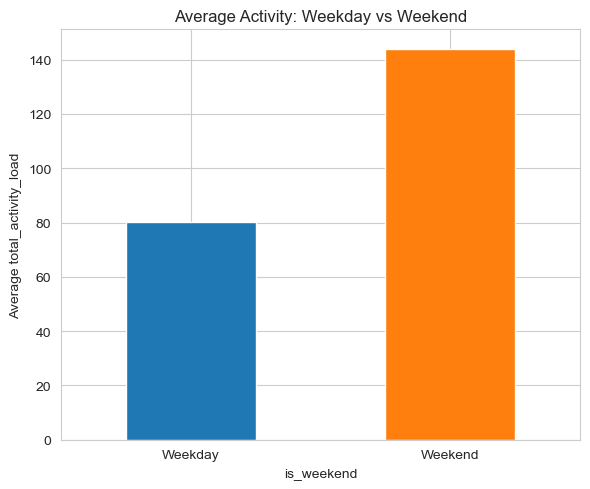

Saved chart2_weekday_vs_weekend.png


In [43]:
# Simple groupby + average comparison

weekday_weekend_avg = df.groupby("is_weekend")["total_activity_load"].mean()
print("\nAverage activity - Weekday vs Weekend:")
print(weekday_weekend_avg)

plt.figure(figsize=(6, 5))
weekday_weekend_avg.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Average Activity: Weekday vs Weekend")
plt.xticks([0, 1], ["Weekday", "Weekend"], rotation=0)
plt.ylabel("Average total_activity_load")
plt.tight_layout()
plt.savefig("chart2_weekday_vs_weekend.png")
plt.show()
print("Saved chart2_weekday_vs_weekend.png")


## STEP 16 : CHART 3 - SEASONAL COMPARISON


Average activity by season:
season
Off-Season        30.003803
Summer (Peak)    171.117964
Name: total_activity_load, dtype: float64


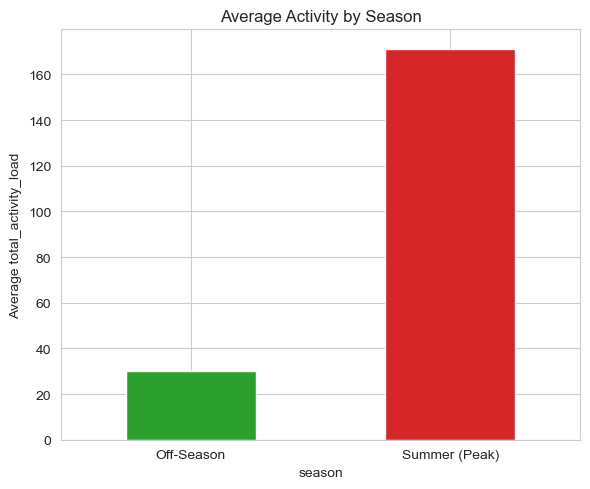

Saved chart3_seasonal.png


In [44]:
seasonal_avg = df.groupby("season")["total_activity_load"].mean()
print("\nAverage activity by season:")
print(seasonal_avg)

plt.figure(figsize=(6, 5))
seasonal_avg.plot(kind="bar", color=["#2ca02c", "#d62728"])
plt.title("Average Activity by Season")
plt.ylabel("Average total_activity_load")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart3_seasonal.png")
plt.show()
print("Saved chart3_seasonal.png")


## STEP 17 : CHART 4 - TIME OF DAY COMPARISON


Average activity by time of day:
time_band
Morning             92.936563
Afternoon          174.378909
Evening             73.568594
Night/Off-hours     19.744654
Name: total_activity_load, dtype: float64


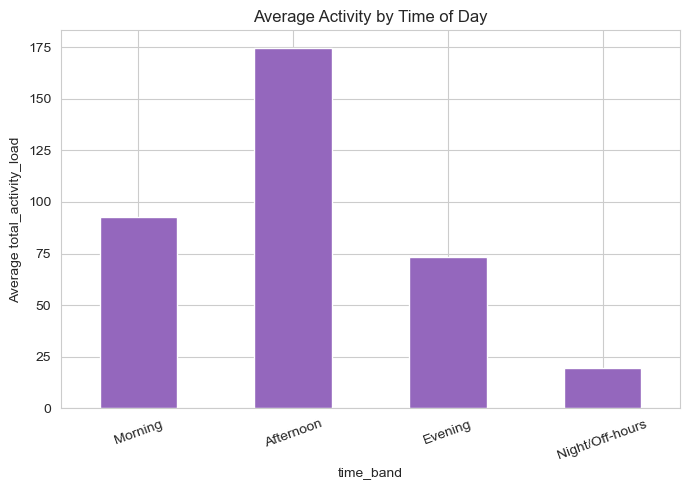

Saved chart4_time_of_day.png


In [45]:
time_band_avg = df.groupby("time_band")["total_activity_load"].mean()
# put them in a logical order instead of alphabetical
time_band_avg = time_band_avg.reindex(["Morning", "Afternoon", "Evening", "Night/Off-hours"])

print("\nAverage activity by time of day:")
print(time_band_avg)

plt.figure(figsize=(7, 5))
time_band_avg.plot(kind="bar", color="#9467bd")
plt.title("Average Activity by Time of Day")
plt.ylabel("Average total_activity_load")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("chart4_time_of_day.png")
plt.show()
print("Saved chart4_time_of_day.png")

## STEP 18 : CHART 5 - HEATMAP (HOUR vs DAY OF WEEK)

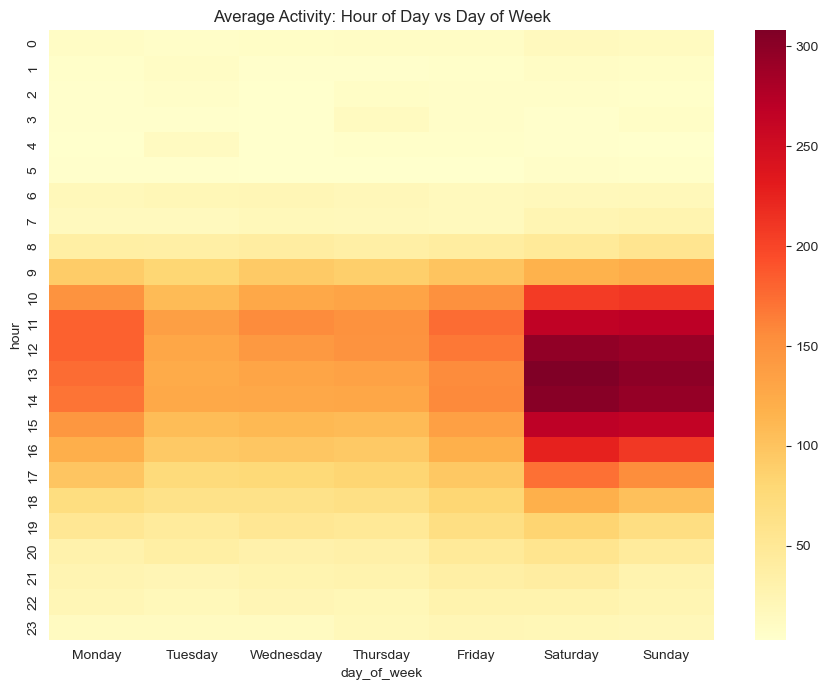

Saved chart5_heatmap.png


In [46]:
# A heatmap is great for spotting patterns like
# "Saturday afternoons are always busiest"

# pivot_table reshapes data: rows=hour, columns=day_of_week, values=average activity
heatmap_data = df.pivot_table(
    index="hour",
    columns="day_of_week",
    values="total_activity_load",
    aggfunc="mean"
)

# put days in proper order (Mon->Sun) instead of alphabetical
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data[[d for d in day_order if d in heatmap_data.columns]]

plt.figure(figsize=(9, 7))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False)
plt.title("Average Activity: Hour of Day vs Day of Week")
plt.tight_layout()
plt.savefig("chart5_heatmap.png")
plt.show()
print("Saved chart5_heatmap.png")


## STEP 19 : TOP CONGESTION AND IDLE WINDOWS (just tables, no chart)

In [47]:
print("\n========== TOP 10 BUSIEST INTERVALS ==========")
top_busy = df.sort_values("total_activity_load", ascending=False).head(10)
print(top_busy[["Timestamp", "total_activity_load", "season", "time_band"]])

print("\n========== TOP 10 QUIETEST (IDLE) INTERVALS ==========")
top_idle = df[df["is_idle_period"]].sort_values("idle_streak_length", ascending=False).head(10)
print(top_idle[["Timestamp", "total_activity_load", "idle_streak_length", "season", "time_band"]])

print("\n✅ DONE! All charts saved in outputs/figures/")


========== TOP 10 BUSIEST INTERVALS ==========
                 Timestamp  total_activity_load         season  \
199913 2023-08-15 20:15:00                14445  Summer (Peak)   
204264 2023-10-10 14:00:00                11053     Off-Season   
221390 2024-06-19 19:00:00                10683  Summer (Peak)   
253769 2025-09-01 17:30:00                10474  Summer (Peak)   
225326 2024-08-05 22:00:00                 9968  Summer (Peak)   
227997 2024-09-07 17:00:00                 9940  Summer (Peak)   
255572 2025-09-24 22:30:00                 8035  Summer (Peak)   
249886 2025-07-17 23:15:00                 7393  Summer (Peak)   
196497 2023-07-05 21:15:00                 7236  Summer (Peak)   
173649 2022-08-15 10:30:00                 6928  Summer (Peak)   

              time_band  
199913          Evening  
204264        Afternoon  
221390          Evening  
253769          Evening  
225326  Night/Off-hours  
227997          Evening  
255572  Night/Off-hours  
249886  Night/Off

In [48]:
import pandas as pd

df = pd.read_csv("fairy_project_feature_engineering.csv")
df.to_csv("fairy_project_feature_engineering.csv.gz", index=False, compression="gzip")

import os
size_mb = os.path.getsize("fairy_project_feature_engineering.csv.gz") / (1024*1024)
print(f"Compressed file size: {size_mb:.2f} MB")

Compressed file size: 5.17 MB


In [49]:
df.columns

Index(['_id', 'Timestamp', 'Redemption Count', 'Sales Count', 'sales_is_spike',
       'redemption_is_spike', 'total_activity_load',
       'redemption_pressure_ratio', 'capacity_utilization_ratio', 'OLI',
       'is_low_activity', 'idle_streak_length', 'is_idle_period',
       'is_high_activity', 'congestion_streak_length', 'is_congestion_period',
       'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'season',
       'time_band'],
      dtype='object')